# California Housing Dataset — Multivariate Linear Regression and Overfitting

In this notebook, we will:
1. Apply linear regression to the California Housing dataset and calculate the loss (RMSE).
2. Increase the model complexity (polynomial features) and observe overfitting.

**Dataset Overview**
- Source: 1990 U.S. Census
- Samples: 20,640
- Features: 8 regional statistics
- Target: Median House Value (unit: $100,000)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from IPython.display import display, Latex

/Users/teshima/Koofr/2026/lecture-supplement-material/Introduction-to-AI/.venv/lib/python3.11/site-packages/sklearn/__init__.py:82: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.3.1)
  import scipy.linalg  # noqa


In [2]:
def format_latex_equation(model, feature_names):
    terms = [f"{c:.3f} \\cdot \\mathrm{{{n}}}" for c, n in zip(model.coef_, feature_names)]
    # Use align* to remove line numbers
    eq = r"\hat{y} &= " + terms[0] + " \\\\ " + " \\\\ ".join([f"&\quad + {t}" for t in terms[1:]])
    eq += f" \\\\ &\quad + {model.intercept_:.3f}"
    return f"\\begin{{align*}}\n{eq}\n\\end{{align*}}"

## 1. Data Loading and Preprocessing

In [3]:
housing = fetch_california_housing()

print("--- Raw Dataset Description (rst) ---")
print(housing.DESCR)

X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = pd.Series(housing.target, name="MedHouseVal")

print("\nOriginal number of samples:", len(y))

--- Raw Dataset Description (rst) ---
.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 

### Dataset Information & License
The description above is provided in reStructuredText (rst) format by the scikit-learn library. 
- **License**: The metadata and the fetcher are part of scikit-learn (BSD 3-Clause License). The dataset itself is derived from the **1990 U.S. Census** and is in the public domain. 
- **Usage**: Printing this metadata at runtime does not impose any restrictive licenses on your own code. 

For a more readable (rendered) version of the key features, please refer to the table in the next section.

### Handling Censored Data
In this dataset, the target variable `MedHouseVal` (Median House Value) is capped at 5.0 (corresponding to $500,000). This is a form of "censoring" often used for privacy protection or because values above a certain threshold are grouped together. 

While such data should ordinarily be handled using specific econometric or statistical techniques (like Tobit regression), for the purpose of this introductory demo, we will simply **remove these capped records** to avoid confusion in our linear regression performance. 

In [4]:
# Remove records where the price is exactly 5.0 (capped)
mask = y < 5.0
X = X[mask]
y = y[mask]

print("Samples after removing capped data:", len(y))

Samples after removing capped data: 19648


## 2. Exploratory Data Analysis

### Feature Description (Rendered Summary)
The following table summarizes the 8 regional features provided in the dataset.

| Variable | Description |
|------------|------------------------------|
| MedInc | Median income in block |
| HouseAge | Median house age in block |
| AveRooms | Average number of rooms |
| AveBedrms | Average number of bedrooms |
| Population | Block population |
| AveOccup | Average house occupancy |
| Latitude | House block latitude |
| Longitude | House block longitude |

**Target variable**: `MedHouseVal` — Median House Value ($100,000s)

In [5]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


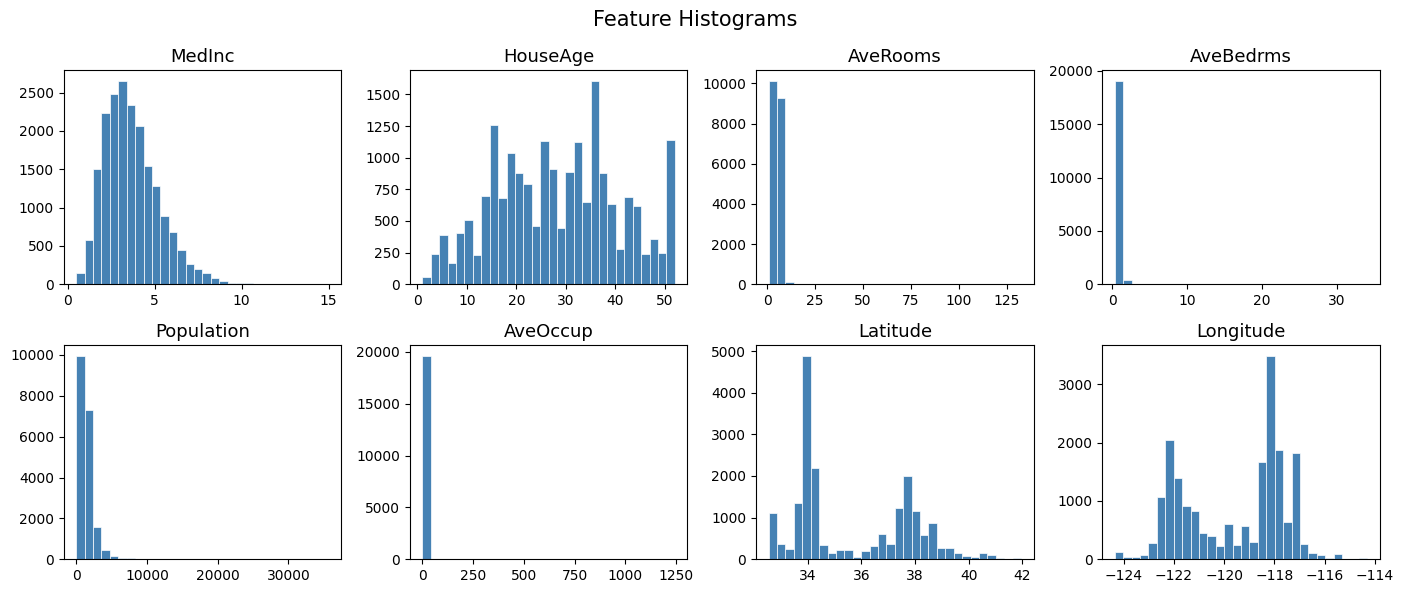

In [6]:
# Feature Histograms
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, col in zip(axes.flatten(), housing.feature_names):
    ax.hist(X[col], bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
    ax.set_title(col, fontsize=13)
    ax.tick_params(labelsize=10)
plt.suptitle("Feature Histograms", fontsize=15)
plt.tight_layout()
plt.show()

## 3. Train-Test Split (Holdout Method)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Training samples: 15718
Test samples: 3930


## 4. Linear Regression

### Model Training

In [8]:
model_lr = LinearRegression(fit_intercept=True)
model_lr.fit(X_train, y_train)

print("Training complete.")

Training complete.


### Learned Equation

In [9]:
print("Learned equation:")
latex_str = format_latex_equation(model_lr, housing.feature_names)
print(latex_str)
display(Latex(latex_str))


Learned equation:
\begin{align*}
\hat{y} &= 0.428 \cdot \mathrm{MedInc} \\ &\quad + 0.008 \cdot \mathrm{HouseAge} \\ &\quad + -0.104 \cdot \mathrm{AveRooms} \\ &\quad + 0.579 \cdot \mathrm{AveBedrms} \\ &\quad + 0.000 \cdot \mathrm{Population} \\ &\quad + -0.003 \cdot \mathrm{AveOccup} \\ &\quad + -0.376 \cdot \mathrm{Latitude} \\ &\quad + -0.392 \cdot \mathrm{Longitude} \\ &\quad + -33.447
\end{align*}


<IPython.core.display.Latex object>

## 5. Model Evaluation

We evaluate the model's accuracy on the training and test sets using the Mean Squared Error (MSE) and its square-root version (RMSE).

### From MSE to RMSE
The Mean Squared Error (MSE) measures the average squared difference between predictions and actual values. However, since the target value is in dollars ($100,000s), the MSE unit is "dollars squared," which is difficult to interpret. 

By taking the **square root of MSE (RMSE)**, we bring the error back to the same unit as the original target variable (dollars), making it easier to understand the magnitude of the model's error.

In [10]:
def evaluate(model, X_tr, X_te, y_tr, y_te):
    # Calculate MSE
    tr_mse = mean_squared_error(y_tr, model.predict(X_tr))
    te_mse = mean_squared_error(y_te, model.predict(X_te))
    
    # Calculate RMSE
    tr_rmse = np.sqrt(tr_mse)
    te_rmse = np.sqrt(te_mse)
    
    print(f"  Train MSE:  {tr_mse:.4f}")
    print(f"  Train RMSE: {tr_rmse:.4f} (approx. ${tr_rmse*100000:.0f})")
    print(f"  Test MSE:   {te_mse:.4f}")
    print(f"  Test RMSE:  {te_rmse:.4f} (approx. ${te_rmse*100000:.0f})")
    return tr_mse, te_mse, tr_rmse, te_rmse

print("--- Performance of Linear Model ---")
lr_results = evaluate(model_lr, X_train, X_test, y_train, y_test)
lr_tr_mse, lr_te_mse, lr_tr_rmse, lr_te_rmse = lr_results

--- Performance of Linear Model ---
  Train MSE:  0.3985
  Train RMSE: 0.6313 (approx. $63130)
  Test MSE:   0.4133
  Test RMSE:  0.6429 (approx. $64286)


### Comparison with Data Variance
In order to make sense of the size of the error, it is advisable to have a simple baseline for comparison. In this case, let us compare the model's performance against the **variance** of the target variable (label).

Variance represents the minimum achievable expected squared error if we were to predict using a single constant value for all cases (this is achieved by using the mean of the target variable as the constant prediction). As such, it is one of the fundamental measures of the underlying dispersion or "spread" in our data. 

If our model's MSE is significantly lower than this variance, it indicates that our features (the regional statistics) provide meaningful information that helps us predict the house values more accurately than simply using the historical average.

In [11]:
test_mean = np.mean(y_test)
data_variance = np.var(y_test)
relative_perf = 1 - (lr_te_mse / data_variance)

print(f"Baseline Constant Prediction (Mean): {test_mean:.4f} (approx. ${test_mean*100000:.0f})")
print(f"Baseline MSE (Variance): {data_variance:.4f}")
print(f"Model's Test MSE:         {lr_te_mse:.4f}")
print(f"Relative performance:    {relative_perf:.2%}")

Baseline Constant Prediction (Mean): 1.9206 (approx. $192064)
Baseline MSE (Variance): 0.9587
Model's Test MSE:         0.4133
Relative performance:    56.89%


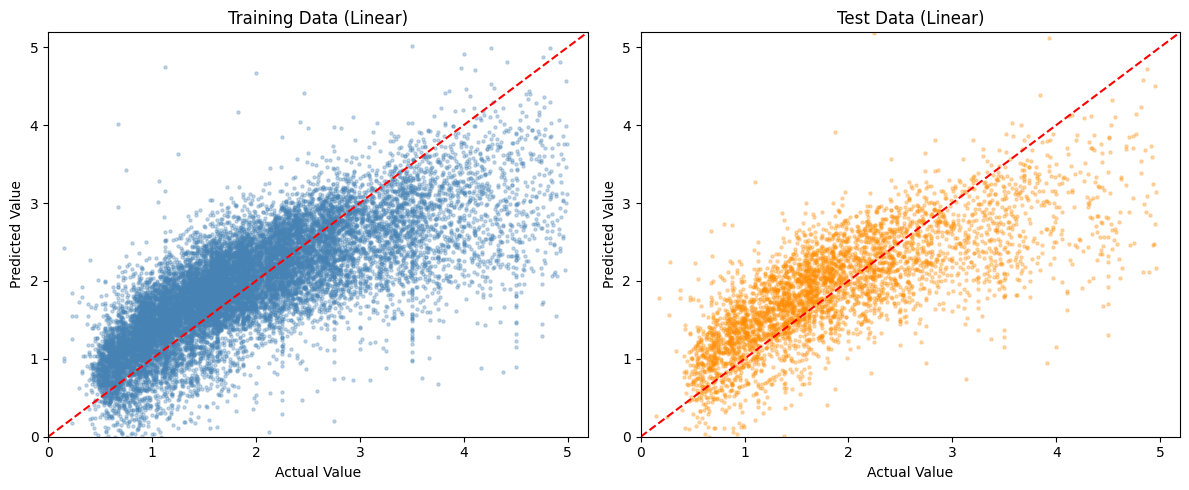

In [12]:
def plot_pred_vs_actual(y_tr, y_tr_p, y_te, y_te_p, title_suffix=""):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    y_max = max(y_tr.max(), y_te.max()) + 0.2
    
    axes[0].scatter(y_tr, y_tr_p, s=5, alpha=0.3, color='steelblue')
    axes[0].plot([0, y_max], [0, y_max], 'r--')
    axes[0].set_title(f"Training Data {title_suffix}")
    
    axes[1].scatter(y_te, y_te_p, s=5, alpha=0.3, color='darkorange')
    axes[1].plot([0, y_max], [0, y_max], 'r--')
    axes[1].set_title(f"Test Data {title_suffix}")
    
    for ax in axes:
        ax.set_xlabel("Actual Value")
        ax.set_ylabel("Predicted Value")
        ax.set_xlim(0, y_max); ax.set_ylim(0, y_max)
    plt.tight_layout()
    return fig

fig = plot_pred_vs_actual(y_train, model_lr.predict(X_train), 
                          y_test, model_lr.predict(X_test), "(Linear)")
plt.show()

## 6. Model Complexity and Overfitting (Degree-3 Polynomial)

We investigate what happens when we drastically increase the model capacity by adding polynomial features (interactions and powers).

In [13]:
# Pipeline: Degree-3 Polynomial Features + Linear Regression
model_poly3 = Pipeline([
    ('poly', PolynomialFeatures(degree=3)),
    ('linear', LinearRegression())
])

model_poly3.fit(X_train, y_train)

num_features = model_poly3.named_steps['linear'].coef_.shape[0]
print(f"Number of features after expansion: {num_features}")

Number of features after expansion: 165


In [14]:
print("--- Performance of Degree-3 Polynomial Model ---")
p3_results = evaluate(model_poly3, X_train, X_test, y_train, y_test)

--- Performance of Degree-3 Polynomial Model ---
  Train MSE:  0.2754
  Train RMSE: 0.5248 (approx. $52481)
  Test MSE:   1.1789
  Test RMSE:  1.0858 (approx. $108576)


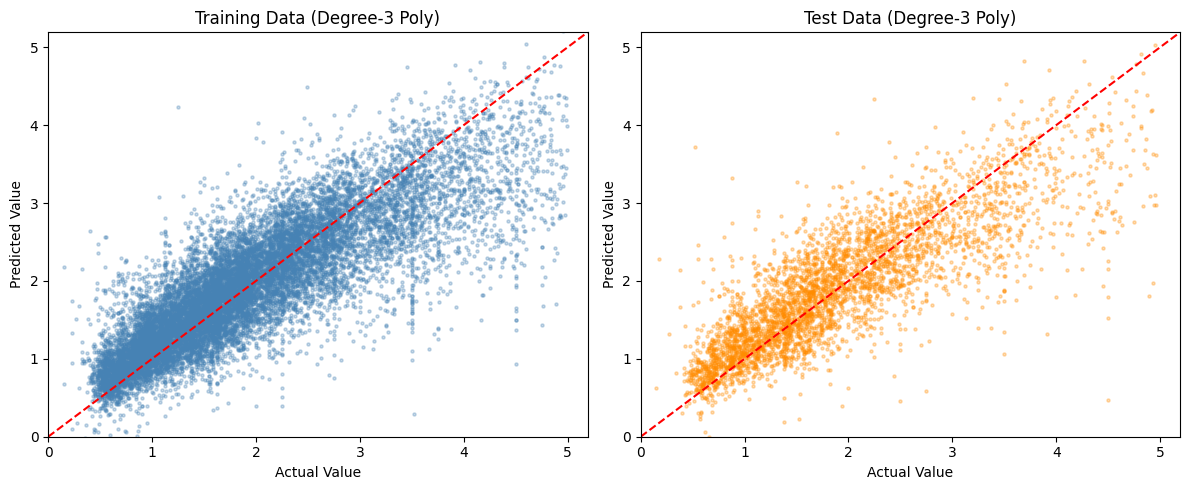

In [15]:
fig = plot_pred_vs_actual(y_train, model_poly3.predict(X_train), 
                          y_test, model_poly3.predict(X_test), "(Degree-3 Poly)")
plt.show()

**Conclusion**:
- Training RMSE **decreased** (better fit on training data).
- Test RMSE **increased** (indicating generalization gap).
This is a typical example of **overfitting**.